# Weighted-average intensity (WAI) as a proxy for uneven barcode density

Investigation for a possible new MERlin task, `SelectOptimizationFovs`:
anecdotal evidence (this repo's author + colleagues) is that when a dataset
has regions with genuinely lower barcode density, running MERlin's
`Optimize` task on randomly-chosen FOVs can hurt barcode retrieval in those
regions. One way `SelectOptimizationFovs` could pick better FOVs: compute a
per-FOV weighted-average intensity (WAI) *before* optimization/decoding ever
runs, and read its distribution shape (unimodal + low std vs. bimodal/wide)
as a signal for uneven barcode density across the sample -- a monomodal,
low-std WAI distribution would suggest uniform density (random-FOV
optimization is fine); a bimodal or wide one would suggest at least one
low-density region worth avoiding when picking optimization FOVs.

**WAI definition used here** (as specified for this investigation): for one
fixed z-plane, take each of the 16 MERFISH combinatorial barcode bits'
readout-channel raw frame for a FOV, compute that frame's mean pixel
intensity, then average those 16 per-bit means into one scalar WAI for the
FOV. This uses only raw acquired frames -- no MERlin `Decode`/`Optimize`
output -- since `SelectOptimizationFovs` would have to run *before* either
of those exist.

**Dataset**: `BC555_sample_05/epi`. `BC553_sample_02/epi` was the second
case originally proposed, but its MERlin output on disk is metadata-only
(`tasks/task.json` per task, no barcode/image data left -- already cleaned
up), so it isn't usable here; this notebook covers `BC555_sample_05/epi`
alone.

**Images produced** (section 6 / section 7):
- a spatial heatmap of WAI per FOV, laid out on the FOV grid (same style as
  `during_imaging/stage_z_drift.ipynb`'s stage-z heatmap)
- a distribution plot (histogram) of WAI per FOV

Follows `NOTEBOOK_GUIDELINES.md` throughout: calculation cells are cached
under `analysis/cache/test_weighted_average_intensity/` and skip already-done
FOVs on rerun, with `ProgressReporter` progress; display cells are separate
and save every figure to `analysis/figures/`.

## 1 — Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import read_image_frames
from MERci.common.experiment_info import resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import find_frame_table_for_hal_config
from MERci.analysis.stage_z       import positions_to_grid_indices
from MERci.progress_display       import ProgressReporter

NOTEBOOK_NAME = "test_weighted_average_intensity"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
# This is a test/investigation notebook (NOTEBOOK_GUIDELINES.md's "validation
# notebooks for a new feature" case under notebooks/tests/) -- it analyzes an
# EXTERNAL dataset, not the experiment this MERci clone is deployed into, so
# SAMPLE_DIR is set explicitly rather than auto-detected from parent dirs.
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi")
IMAGE_SUFFIX = ".zarr"

# The 16 combinatorial MERFISH bits (codebook_0_C3v1_codebook.csv has exactly
# 16 RS-readout columns); round_bit_color_map.csv's bit numbers 17+ are the
# non-combinatorial "sequential genes" readout, excluded here.
N_BARCODE_BITS = 16

Z_PLANE = None   # None = auto-pick the middle z of the bits round's frame table (section 4)

FORCE_RECOMPUTE = False

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"SAMPLE_DIR: {SAMPLE_DIR}")

SAMPLE_DIR: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi


## 3 — Resolve dataset geometry

In [3]:
sample_name, imaging_dir = resolve_sample_identity(SAMPLE_DIR / "MERci")
positions_tag = positions_file_tag(sample_name, imaging_dir)

config = ExperimentConfig(
    data_dir       = SAMPLE_DIR / "data",
    metadata_dir   = SAMPLE_DIR / "metadata",
    analysis_dir   = SAMPLE_DIR / "analysis",
    settings_dir   = SAMPLE_DIR / "settings",
    round_info_csv = SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt  = SAMPLE_DIR / "positions" / f"positions_{positions_tag}.txt",
    image_suffix   = IMAGE_SUFFIX,
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)

# NOTEBOOK_GUIDELINES.md #2: cache under analysis/cache/<notebook_name>/.
CACHE_DIR = config.analysis_dir / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / "wai_per_fov.csv"

# NOTEBOOK_GUIDELINES.md #6: figures under analysis/figures/{NOTEBOOK_NAME}.{name}.png.
FIGURES_DIR = config.analysis_dir / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

round_info = pd.read_csv(config.round_info_csv)

print(f"Sample name: {sample_name}")
print(f"FOVs       : {meta.n_fovs}")
print(f"Rounds     : {meta.n_rounds}")
print(f"Cache      : {CACHE_PATH}")
print(f"Figures    : {FIGURES_DIR}")

Sample name: BC555_sample_05
FOVs       : 476
Rounds     : 10
Cache      : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_weighted_average_intensity/wai_per_fov.csv
Figures    : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/figures


## 4 — Map each barcode bit to a (round, frame index) at one fixed z

`round_bit_color_map.csv` gives, per barcoding round, which bit number was
read out in which color -- but its own `round` column is a 1-indexed
position *within the bits rounds only* (H01=1, H02=2, ...), not
`round_info.csv`'s `imaging_round` (which also counts the earlier `cells`
round, so H01 there is `imaging_round=2`). Translate by position: the
`round_info.csv` rows with `imaging_type == "bits"`, sorted by
`imaging_round`, are H01, H02, ... in that same order.

Every "bits" round shares one frame table (same HAL config across
H01-H08), so it's read once; a frame's `(color, z)` pair identifies its
index within that shared per-round frame stack. `Z_PLANE` (if left `None`)
is the middle z of the range imaged for the barcode colors -- an arbitrary
but reproducible single-z choice, per this investigation's WAI definition
(section 0).

In [4]:
round_bit_color = pd.read_csv(config.metadata_dir / "round_bit_color_map.csv")
bits_df = round_bit_color[round_bit_color["bit"] <= N_BARCODE_BITS].sort_values("bit").reset_index(drop=True)
assert len(bits_df) == N_BARCODE_BITS, (
    f"Expected {N_BARCODE_BITS} combinatorial bits, found {len(bits_df)} with bit <= {N_BARCODE_BITS} "
    f"in {config.metadata_dir / 'round_bit_color_map.csv'} -- check N_BARCODE_BITS / the codebook."
)

# round_bit_color_map.csv's own "round" (1..n_bits_rounds) -> round_info.csv's imaging_round.
bits_rounds_info = round_info.loc[round_info["imaging_type"] == "bits"].sort_values("imaging_round")
bits_round_to_imaging_round = {i + 1: int(r) for i, r in enumerate(bits_rounds_info["imaging_round"])}

bits_round_ids = sorted(int(r) for r in bits_df["round"].unique())
bits_series_by_round = {
    rid: meta.series_for_round(bits_round_to_imaging_round[rid], imaging_type="bits")[0]
    for rid in bits_round_ids
}

# All "bits" rounds share one HAL config/frame table (round_info.csv's hal_config
# column is identical across H01-H08) -- read it once from the first bits round.
first_bits_round  = bits_rounds_info.iloc[0]
hal_config_path   = config.settings_dir / first_bits_round["hal_config"]
frame_table_path  = find_frame_table_for_hal_config(hal_config_path, config.metadata_dir)
frame_table       = pd.read_csv(frame_table_path)

barcode_colors = sorted(bits_df["color"].astype(float).unique())
barcode_z_values = sorted(frame_table.loc[frame_table["color"].isin(barcode_colors), "z"].unique())
if Z_PLANE is None:
    Z_PLANE = barcode_z_values[len(barcode_z_values) // 2]

# {bit: (round_id, frame_index)} -- round_id here is round_bit_color_map's own
# round number, matching bits_series_by_round's keys above.
bit_lookup = {}
for _, row in bits_df.iterrows():
    match = frame_table[(frame_table["color"] == float(row["color"])) & (frame_table["z"] == Z_PLANE)]
    if len(match) != 1:
        raise ValueError(f"Expected exactly one frame at color={row['color']}, z={Z_PLANE}; found {len(match)}.")
    bit_lookup[int(row["bit"])] = (int(row["round"]), int(match.index[0]))

print(f"Barcode colors (nm)          : {barcode_colors}")
print(f"z-planes available for those : {barcode_z_values}")
print(f"Z_PLANE (chosen)             : {Z_PLANE}")
for bit, (rid, fidx) in sorted(bit_lookup.items()):
    print(f"  bit {bit:2d}: round {rid} (imaging_round {bits_round_to_imaging_round[rid]}), frame {fidx}")

Barcode colors (nm)          : [np.float64(650.0), np.float64(750.0)]
z-planes available for those : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
Z_PLANE (chosen)             : 13
  bit  1: round 1 (imaging_round 2), frame 37
  bit  2: round 1 (imaging_round 2), frame 38
  bit  3: round 2 (imaging_round 3), frame 37
  bit  4: round 2 (imaging_round 3), frame 38
  bit  5: round 3 (imaging_round 4), frame 37
  bit  6: round 3 (imaging_round 4), frame 38
  bit  7: round 4 (imaging_round 5), frame 37
  bit  8: round 4 (imaging_round 5), frame 38
  bit  9: round 5 (imaging_round 6), frame 37
  bit 10: round 5 (imaging_round 6), frame 38
  bit 11: round 6 (imaging_round 7), frame 37
  bit 12: round 6

## 5 — Calculation: per-FOV WAI

**Calculation cell** (`NOTEBOOK_GUIDELINES.md` #1/#2/#3/#4): for every FOV,
reads the 16 barcode-bit frames resolved in section 4 (one z-plane, true
partial reads via `read_image_frames`, never the full stack) and averages
their per-frame means into one WAI value. Cached to
`analysis/cache/test_weighted_average_intensity/wai_per_fov.csv`; already-cached
FOVs are skipped on rerun unless `FORCE_RECOMPUTE`.

In [5]:
if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    cache_df = pd.read_csv(CACHE_PATH)
else:
    cache_df = pd.DataFrame(columns=["fov_id", "wai"])

done_fovs    = set(cache_df["fov_id"])
all_fov_ids  = sorted(meta.fovs)
todo_fov_ids = [f for f in all_fov_ids if f not in done_fovs]

print(f"{len(done_fovs)} / {len(all_fov_ids)} FOV(s) already cached; computing {len(todo_fov_ids)} more.")

new_rows = []
reporter = ProgressReporter(total=len(todo_fov_ids), label="Computing per-FOV WAI")
for fov_id in todo_fov_ids:
    bit_means = []
    for bit, (round_id, frame_idx) in bit_lookup.items():
        series = bits_series_by_round[round_id]
        path   = series.resolve_path(fov_id, config.image_suffix)
        frame  = read_image_frames(path, [frame_idx])[0]
        bit_means.append(float(frame.mean()))
    new_rows.append({"fov_id": fov_id, "wai": float(np.mean(bit_means))})
    reporter.update()
reporter.done()

if new_rows:
    cache_df = pd.concat([cache_df, pd.DataFrame(new_rows)], ignore_index=True)
    cache_df = cache_df.drop_duplicates(subset="fov_id").sort_values("fov_id").reset_index(drop=True)
    cache_df.to_csv(CACHE_PATH, index=False)

print(f"WAI computed for {len(cache_df)} FOV(s). Cache: {CACHE_PATH}")

0 / 476 FOV(s) already cached; computing 476 more.


Computing per-FOV WAI: [------------------------] 1/476 (  0.2%)  elapsed 1s  ETA 5m 0s          

Computing per-FOV WAI: [------------------------] 3/476 (  0.6%)  elapsed 2s  ETA 4m 0s          

Computing per-FOV WAI: [------------------------] 4/476 (  0.8%)  elapsed 2s  ETA 4m 3s          

Computing per-FOV WAI: [------------------------] 6/476 (  1.3%)  elapsed 3s  ETA 3m 58s          

...

Computing per-FOV WAI: [#######################-] 474/476 ( 99.6%)  elapsed 8m 41s  ETA 2s          

Computing per-FOV WAI: [#######################-] 475/476 ( 99.8%)  elapsed 8m 43s  ETA 1s          

Computing per-FOV WAI: [########################] 476/476 (100.0%)  elapsed 8m 44s  ETA 0s          

Computing per-FOV WAI: [########################] 476/476 (100.0%)  elapsed 8m 44s  ETA 0s          


WAI computed for 476 FOV(s). Cache: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_weighted_average_intensity/wai_per_fov.csv


## 6 — Spatial heatmap of WAI per FOV

Same layout idiom as `during_imaging/stage_z_drift.ipynb`'s stage-z
heatmap: stage `(x, y)` -> integer grid index
(`MERci.analysis.stage_z.positions_to_grid_indices`), filled with each
FOV's WAI.

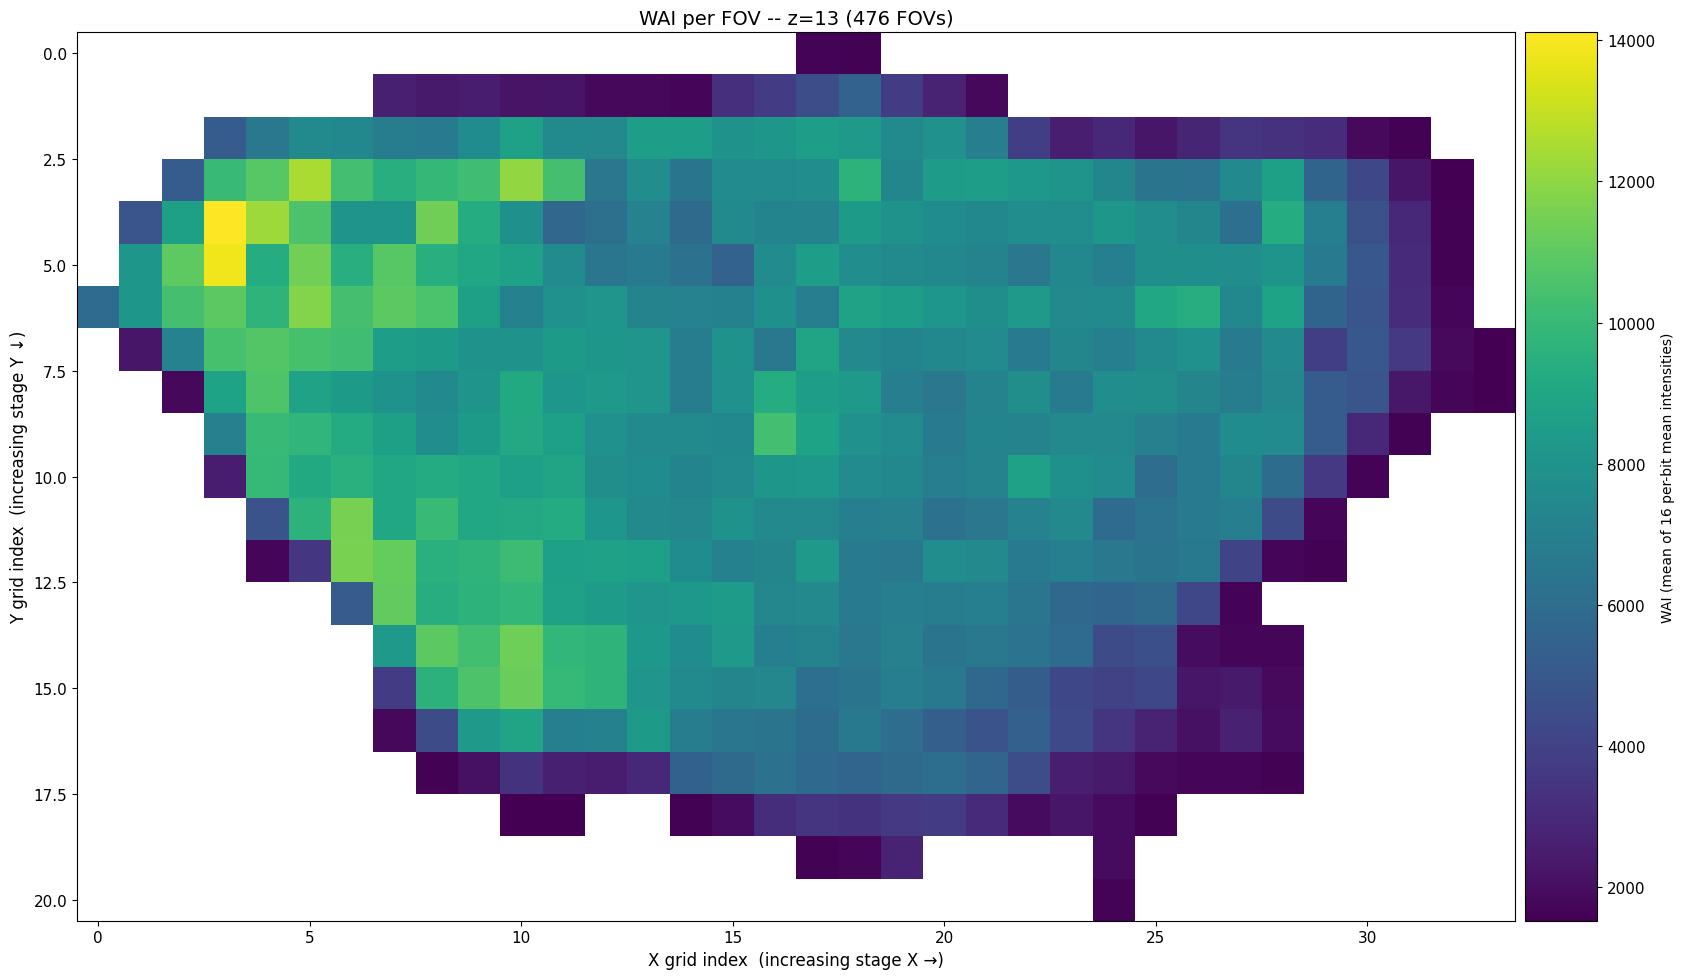

In [6]:
fov_ids = cache_df["fov_id"].tolist()
grid    = positions_to_grid_indices(fov_ids, meta)
n_x     = max(xi for xi, _ in grid.values()) + 1
n_y     = max(yi for _, yi in grid.values()) + 1

matrix = np.full((n_y, n_x), np.nan)
for fov_id, wai in zip(cache_df["fov_id"], cache_df["wai"]):
    xi, yi = grid[fov_id]
    matrix[yi, xi] = wai

fig, ax = plt.subplots(figsize=(max(9, n_x * 0.7 + 3), max(4, n_y * 0.4 + 1.5)))
im = ax.imshow(matrix, cmap="viridis", origin="upper")
ax.set_title(f"WAI per FOV -- z={Z_PLANE} ({len(fov_ids)} FOVs)", fontsize=PLOT_TITLE_FONTSIZE)
ax.set_xlabel("X grid index  (increasing stage X \u2192)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Y grid index  (increasing stage Y \u2193)", fontsize=PLOT_LABEL_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(im, cax=cax, label="WAI (mean of 16 per-bit mean intensities)")
cbar.ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.wai_heatmap.png", dpi=150)
plt.show()

## 7 — Distribution of WAI per FOV

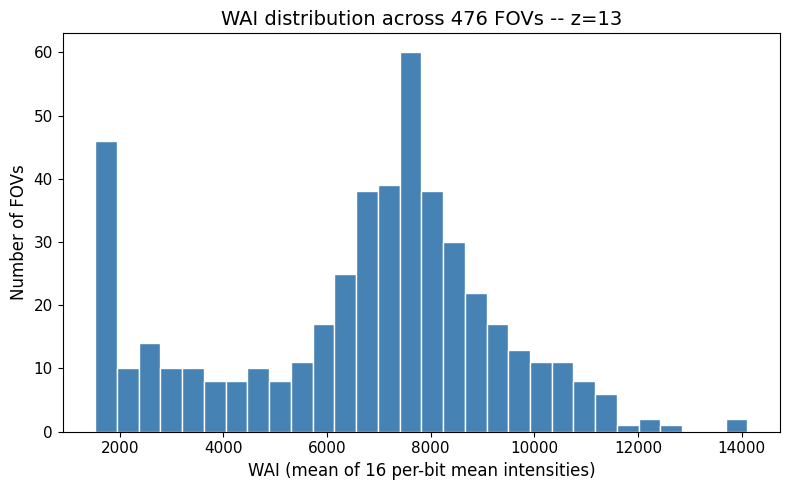

WAI: mean=6654.4882  std=2662.7107  cv=0.4001


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(cache_df["wai"], bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("WAI (mean of 16 per-bit mean intensities)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Number of FOVs", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"WAI distribution across {len(cache_df)} FOVs -- z={Z_PLANE}", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.wai_distribution.png", dpi=150)
plt.show()

print(f"WAI: mean={cache_df['wai'].mean():.4f}  std={cache_df['wai'].std():.4f}  "
      f"cv={cache_df['wai'].std() / cache_df['wai'].mean():.4f}")